In [51]:
import numpy as np
import rioxarray as rix 
import matplotlib.pyplot as plt
import geopandas as gdf
from skimage import measure, morphology
import geopandas as gpd
from shapely.geometry import shape
import rasterio
from rasterio import features
from rasterio.features import shapes

In [3]:
#data = r"C:\Users\amonson\Documents\408\HW_4\m_3508228_nw_17_060_20220923.tif"

In [4]:
data=r"C:\Users\agmon\Documents\408\hw4\m_3508228_nw_17_060_20220923.tif"

In [5]:
Asheville= rix.open_rasterio(data)

In [6]:
Asheville

<xarray.DataArray (band: 4, y: 12380, x: 10300)> Size: 510MB
[510056000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 99kB 3.944e+06 3.944e+06 ... 3.936e+06 3.936e+06
  * x            (x) float64 82kB 3.525e+05 3.525e+05 ... 3.587e+05 3.587e+05
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

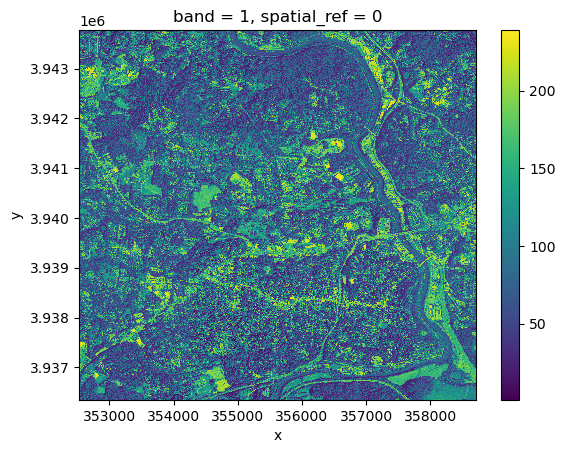

In [7]:
Asheville[0].plot()

In [8]:
RGB_Asheville = Asheville[:3].values.transpose(1, 2, 0)

In [9]:
red = Asheville[2].astype('float32')
NIR = Asheville[3].astype('float32')

In [10]:
ndvi_array = (NIR - red) / (NIR + red + 1e-6)

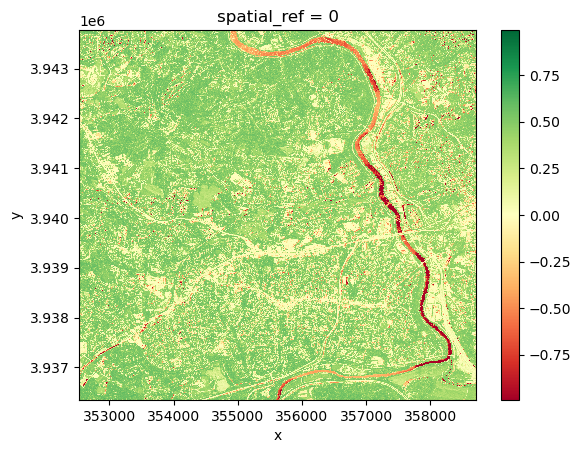

In [12]:
ndvi_array.plot.imshow(cmap='RdYlGn')

Error: ndvi_array is a <class 'xarray.core.dataarray.DataArray'>, not a NumPy array.


In [13]:
ndvi_numpy = ndvi_array.to_numpy()
min_building_area=50
building_mask = ((ndvi_numpy < 0.2).astype(np.uint8))
print("sucess")

sucess


In [14]:
from skimage.measure import label 
label_buildings = label(building_mask)
print(f"Detected {label_buildings.max()} potential objects.")

Detected 156059 potential objects.


In [17]:
from skimage.measure import regionprops
def filter_buildings(labeled_img, min_area):
    props = regionprops(labeled_img)
    cleaned_mask = np.zeros(labeled_img.shape, dtype=np.uint8)
    cleaned_mask = np.zeros(ndvi_array.shape, dtype=np.uint8)
    
    for prop in props:
        if prop.area > min_area:
            cleaned_mask[tuple(prop.coords.T)] = 1
    return cleaned_mask
    
final_buildings = filter_buildings(label_buildings, min_building_area)



<function matplotlib.pyplot.show(close=None, block=None)>

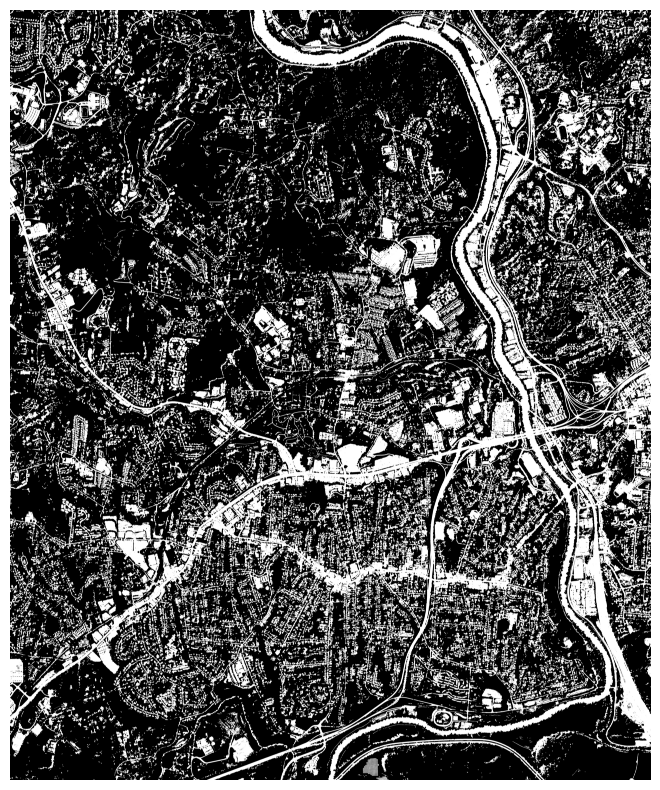

In [18]:
plt.figure(figsize=(10,10))
plt.imshow(final_buildings, cmap='gray')
plt.axis('off')
plt.show

In [41]:
results = (
    {'properties':{'raster_val' : v}, 'geometry': s}
        for i, (s,v) in enumerate(features.shapes(final_buildings, transform=Asheville.rio.transform()))
        if v ==1
    )

In [42]:
src= rasterio.open(r"C:\Users\agmon\Documents\408\hw4\m_3508228_nw_17_060_20220923.tif")

In [43]:
GeoDataFramegdf=gpd.GeoDataFrame.from_features(results, crs=src.crs)

geom= list(results)
gdf = gpd.GeoDataFrame.from_features([
{'geometry': shape(item['geometry']), 'raster_val': item['properties']['raster_val'])}
for item in results])




In [46]:
GeoDataFramegdf.to_file("Asheville_Buildings.shp")
print(f"GDF created")


C:\Users\agmon\Documents\408\hw4\.pixi\envs\default\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


GDF created


<Axes: >

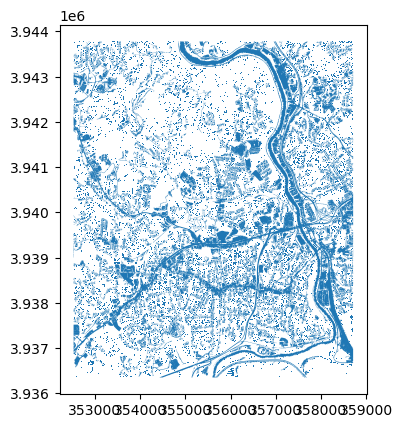

In [50]:
GeoDataFramegdf.plot()